# Model Analysis: S&P 500 Equity + Option Analytics

This notebook evaluates models trained on the S&P 500 equity+option
case study across predictive (Ch11-13), structural (Ch14), and causal
(Ch15) approaches. The goal is to identify which signals merit simulation,
subject to the uncertainty and two-fold limitations reported below.

This case study starts from the book's largest configured equity roster
(633 current S&P 500 constituents at daily frequency) and is the only one
that combines traditional
equity features with option-derived features - implied volatility surfaces,
put-call ratios, IV skew, term structure, and the implied-realized
volatility spread. The central question is not just "can we predict?"
but **"do option-derived features add predictive power, and if so, through
what mechanism - direct prediction or latent factor extraction?"**

The S&P 500 is the most analyzed equity universe on the planet. Direct
supervised prediction of weekly forward returns ($fwd\_ret\_5d$) proves
difficult. The corrected registry instead points to target-specific
structural evidence: PCA clears zero at the 10-day and risk-adjusted
horizons, while no family clears zero on the primary weekly target.

With only 2 expanding-window folds, stability analysis is inherently
limited. All fold-level conclusions carry a strong caveat: two
observations do not establish robustness. The statistical power comes
instead from the broad cross-section, which supplies hundreds of names per
bucket but cannot establish stability across time.

**Population scope**: The source universe is a current-constituent roster,
not point-in-time S&P 500 membership. Historical performance describes this
retrospective roster and does not generalize to the index-membership process
or a prospective S&P 500 population.

**Learning Objectives**:
- Apply a structured model evaluation workflow to a real dataset
- Compare predictive, structural, and causal model evidence
- Assess whether option-derived features add value through factor extraction
- Use decile analysis to detect ranking ability even when supervised IC is near zero
- Make explicit, evidence-based decisions about which models to backtest

**Prerequisites**: Model training notebooks Ch11-15 must have run for this
case study. Linear and GBM results come from the registry; TabM, DL,
latent factor, and causal DML results come from the training pipeline.

**Book Reference**: This notebook bridges Part III (Models, Ch11-15) and
Part IV (Strategy Implementation, Ch16-20). The chapter insights notebooks
in Ch11-15 compare each model family *across* case studies; here we compare
all families *within* a single dataset - with particular focus on the
option feature question and the structural vs predictive distinction
that make this case study unique.

In [1]:
"""Compare model families for the S&P 500 equity and option case study."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch  # cudart preload - required before ml4t.diagnostic imports # noqa: F401
import yaml

from case_studies.utils.latent_factors import load_fold_extras
from case_studies.utils.model_analysis import (
    best_model_per_family_fast,
    fold_performance_matrix,
    load_all_metrics,
    load_fold_metrics_from_registry,
    load_gbm_feature_importance,
    load_predictions,
    prediction_bucket_monotonicity,
    prediction_correlation_matrix,
    regime_conditional_ic,
)
from case_studies.utils.model_viz import (
    plot_bucket_monotonicity,
    plot_correlation_matrix,
    plot_cv_timeline,
    plot_feature_importance_heatmap,
    plot_fold_boxplot,
    plot_fold_heatmap,
    plot_label_horizon_forest,
    plot_learning_curves,
    plot_regime_bars,
)
from case_studies.utils.notebook_render import conformal_coverage_diagnostic
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY = "sp500_equity_option_analytics"
PRIMARY_LABEL = "fwd_ret_5d"
DATE_COL = "timestamp"
ENTITY_COL = "symbol"
N_BUCKETS = 10
TOP_N_FEATURES = 15
REGIME_WINDOW = 63

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

n_splits = setup["evaluation"]["n_splits"]
train_size = setup["evaluation"]["train_size"]
val_size = setup["evaluation"]["val_size"]
holdout_start = setup["evaluation"].get("holdout_start")
n_assets = setup["universe"]["n_assets"]
cost_range = setup["costs"]["per_leg_cost_bps_range"]  # [3, 10]

print(f"Case Study: {CASE_STUDY}")
print(f"  Universe: {n_assets} S&P 500 stocks (with listed options)")
print(f"  Label: {PRIMARY_LABEL} (weekly forward return)")
print(f"  CV: {n_splits} expanding-window folds, train={train_size}, val={val_size}")
print(f"  Holdout: {holdout_start} onwards")
print(f"  Trading costs: {cost_range[0]}–{cost_range[1]} bps per leg")

Case Study: sp500_equity_option_analytics
  Universe: 633 S&P 500 stocks (with listed options)
  Label: fwd_ret_5d (weekly forward return)
  CV: 2 expanding-window folds, train=2Y, val=1Y
  Holdout: 2021-01-01 onwards
  Trading costs: 3–10 bps per leg


## 1. What Is the Prediction Problem?

**Primary target tuple**: `fwd_ret_5d` | regression | IC | weekly rebalancing

We predict the 5-trading-day forward return for eligible S&P 500
constituents, ranking them cross-sectionally each week to identify
stocks with the highest expected short-term returns. The strategy
buys the top-ranked stocks and rebalances weekly.

The 48-feature set combines three broad categories:

1. **Equity features**: momentum at multiple horizons (5d to 252d),
   risk-adjusted momentum, realized volatility (20d, 63d), Garman-Klass
   vol, vol-of-vol, and cross-sectional ranks.
2. **Option-derived features**: 30-day ATM implied volatility,
   7-day and 90-day ATM IV, 25-delta put and call IV, risk-reversal
   skew, IV term structure slope and convexity, IV momentum (5d, 21d),
   IV z-scores, and the implied-realized volatility spread.
3. **Model-based volatility features**: GARCH conditional volatility,
   volatility surprise, and the GARCH-based IV-RV spread.

The configured roster contains 633 current S&P 500 stocks with listed options.
After feature and label availability, the current validation leaders cover
543 to 550 distinct stocks. This remains the largest equity cross-section in
the book, but many observations per bucket do not replace time-series evidence.
Trading costs are 3-10 bps per leg,
reflecting the high liquidity of S&P 500 large caps.

The evaluation uses 2 expanding-window folds with 2-year training
and 1-year validation, with a holdout period from 2021 onwards. The
limited fold count is a significant constraint: all fold-level
conclusions carry a caveat about small-sample stability.

In [4]:
# Phase 1: Load pre-computed metrics (fast - no raw prediction loading)
raw_metrics = load_all_metrics(CASE_STUDY, label=None).filter(pl.col("label").is_not_null())
all_labels_metrics = (
    raw_metrics.with_columns(
        pl.col("ic_n_days").max().over(["family", "label"]).alias("_family_label_days")
    )
    .filter(
        pl.col("ic_n_days").is_not_null(),
        pl.col("ic_n_days") == pl.col("_family_label_days"),
    )
    .drop("_family_label_days")
)
all_metrics = all_labels_metrics.filter(pl.col("label") == PRIMARY_LABEL)

if all_metrics.height == 0:
    raise RuntimeError(f"No metrics found for {CASE_STUDY} / {PRIMARY_LABEL}")

families_present = sorted(all_metrics["family"].unique().to_list())
excluded_partial = raw_metrics.height - all_labels_metrics.height
print(f"Pre-computed metrics: {all_metrics.height} entries across {len(families_present)} families")
print(f"  Excluded partial-coverage variants: {excluded_partial}")

for fam in families_present:
    sub = all_metrics.filter(pl.col("family") == fam)
    configs = sub["config_name"].n_unique()
    checkpoints = sub["checkpoint_value"].drop_nulls().n_unique()
    best_ic = sub["ic_mean_daily"].max()
    best_ic_text = f"{best_ic:+.4f}" if best_ic is not None else "n/a"
    print(
        f"  {fam:20s}  {configs:3d} configs  {checkpoints:3d} checkpoints  best IC={best_ic_text}"
    )

Pre-computed metrics: 90 entries across 5 families
  Excluded partial-coverage variants: 0
  deep_learning           3 configs    2 checkpoints  best IC=+0.0105
  gbm                    15 configs    4 checkpoints  best IC=+0.0074
  latent_factors          5 configs   19 checkpoints  best IC=+0.0124
  linear                 28 configs    0 checkpoints  best IC=-0.0062
  tabular_dl              3 configs    4 checkpoints  best IC=+0.0156


The family census prevents a partial registry from silently becoming the
model leaderboard.

In [5]:
EXPECTED_METRIC_FAMILIES = {"linear", "gbm", "tabular_dl", "deep_learning", "latent_factors"}
missing = EXPECTED_METRIC_FAMILIES - set(families_present)
if missing:
    n_present = len(families_present)
    print(
        f"\nWARNING: {n_present}/{len(EXPECTED_METRIC_FAMILIES)} predictive/structural "
        f"families present. Missing: {', '.join(sorted(missing))}"
    )
    print("  Recommendations below may change when missing families are added.")
else:
    print("\nFull predictive/structural coverage: all 5 metric families present.")


Full predictive/structural coverage: all 5 metric families present.


In [6]:
# Best model per family
best_per_family = best_model_per_family_fast(all_metrics)

print("\nBest model per family:")
print(
    best_per_family.select(
        ["family", "config_name", "checkpoint_value", "ic_mean_daily", "ic_se_hac"]
    )
)


Best model per family:
shape: (5, 5)
┌────────────────┬───────────────┬──────────────────┬───────────────┬───────────┐
│ family         ┆ config_name   ┆ checkpoint_value ┆ ic_mean_daily ┆ ic_se_hac │
│ ---            ┆ ---           ┆ ---              ┆ ---           ┆ ---       │
│ str            ┆ str           ┆ i64              ┆ f64           ┆ f64       │
╞════════════════╪═══════════════╪══════════════════╪═══════════════╪═══════════╡
│ tabular_dl     ┆ tabm_s        ┆ 75               ┆ 0.015589      ┆ 0.009379  │
│ latent_factors ┆ sdf           ┆ 0                ┆ 0.012446      ┆ 0.015944  │
│ deep_learning  ┆ nlinear       ┆ 5                ┆ 0.010526      ┆ 0.010569  │
│ gbm            ┆ default_huber ┆ 500              ┆ 0.007394      ┆ 0.008353  │
│ linear         ┆ ridge_a100.0  ┆ null             ┆ -0.006173     ┆ 0.014314  │
└────────────────┴───────────────┴──────────────────┴───────────────┴───────────┘


In [7]:
# Phase 2a: Load per-fold metrics from registry (fast path - no raw predictions needed)
fold_metrics = load_fold_metrics_from_registry(CASE_STUDY, label=PRIMARY_LABEL)
if fold_metrics.height > 0:
    print(f"Fold metrics from registry: {fold_metrics.height} entries")
else:
    print("No fold_metrics table - will compute from raw predictions")

Fold metrics from registry: 180 entries


In [8]:
# Phase 2: Load raw predictions ONLY for the ~5 best models (not all 47M+)
representative_preds = []

for row in best_per_family.filter(pl.col("family") != "causal_dml").iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    preds = load_predictions(
        CASE_STUDY,
        prediction_hash=row["prediction_hash"],
        family=family,
        label=PRIMARY_LABEL,
        config_name=config,
        checkpoint_value=checkpoint,
    )
    if preds.height > 0:
        representative_preds.append(preds)
        print(f"  Loaded {family}/{config}: {preds.height:,} predictions")

if representative_preds:
    best_preds = pl.concat(representative_preds, how="diagonal_relaxed")
    print(f"\nTotal representative predictions: {best_preds.height:,}")
else:
    best_preds = pl.DataFrame()
    print("WARNING: No raw predictions could be loaded")

  Loaded tabular_dl/tabm_s: 210,739 predictions
  Loaded latent_factors/sdf: 210,739 predictions
  Loaded deep_learning/nlinear: 207,646 predictions
  Loaded gbm/default_huber: 210,739 predictions
  Loaded linear/ridge_a100.0: 210,739 predictions

Total representative predictions: 1,050,602


In [9]:
# Fold date ranges for timeline
if best_preds.height > 0:
    _date_dtype = best_preds[DATE_COL].dtype
    if _date_dtype == pl.String:
        _date_expr = pl.col(DATE_COL).str.to_datetime(strict=False).cast(pl.Date)
    else:
        _date_expr = pl.col(DATE_COL).cast(pl.Date)
    fold_ranges = (
        best_preds.filter(pl.col("fold_id").is_not_null())
        .with_columns(_date_expr)
        .group_by("fold_id")
        .agg(
            pl.col(DATE_COL).min().alias("val_start"),
            pl.col(DATE_COL).max().alias("val_end"),
        )
        .sort("fold_id")
    )

### Validation Outcomes Stop Before the Holdout

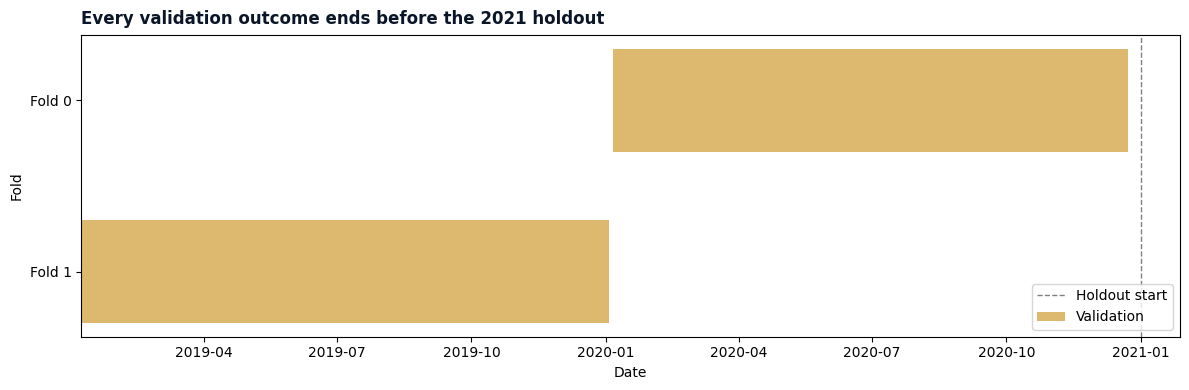

In [10]:
if best_preds.height > 0 and fold_ranges.height > 0:
    plot_cv_timeline(
        fold_ranges,
        n_splits,
        holdout_start,
        title="Every validation outcome ends before the 2021 holdout",
    )

With only 2 folds, the cross-validation design is minimal. Fold 0
trains on the first 2 years and validates on year 3; fold 1 expands
the training window and validates on a later year. The holdout
period (2021 onwards) is never used for model selection.

The 2-fold limitation means we cannot distinguish systematic
performance from period-specific luck. The expanding window gives
fold 1 more training data, but if fold 1 happens to cover a
regime that favors momentum (or mean-reversion), we cannot
separate the effect of more data from the effect of a favorable
market environment. This caveat applies to every fold-level
conclusion in this notebook.

## 2. What Was Actually Run?

Before comparing results, we map what is actually comparable. Not all
model families were trained on all labels, and the five modeling
chapters contribute different kinds of evidence: Ch11-13 produce
predictive forecasts; Ch14 extracts latent structure; Ch15 estimates
causal effects. Forcing all of these into a single ranking would be
misleading.

In [11]:
# Coverage map: family × label × evidence type
EVIDENCE_TYPE = {
    "linear": "predictive",
    "gbm": "predictive",
    "tabular_dl": "predictive",
    "deep_learning": "predictive",
    "latent_factors": "structural",
    "causal_dml": "causal",
}
FAMILY_CHAPTER = {
    "linear": "Ch11",
    "gbm": "Ch12",
    "tabular_dl": "Ch12",
    "deep_learning": "Ch13",
    "latent_factors": "Ch14",
    "causal_dml": "Ch15",
}

coverage = (
    raw_metrics.group_by(["family", "label"])
    .agg(pl.col("config_name").n_unique().alias("n_configs"))
    .join(
        all_labels_metrics.group_by(["family", "label"]).agg(
            pl.col("ic_mean_daily").max().alias("best_ic")
        ),
        on=["family", "label"],
        how="left",
    )
    .with_columns(
        chapter=pl.col("family").replace(FAMILY_CHAPTER),
        evidence=pl.col("family").replace(EVIDENCE_TYPE),
    )
    .sort(["family", "label"])
)

print("Coverage Map: Families × Labels")
print(coverage.select(["chapter", "family", "label", "evidence", "n_configs", "best_ic"]))

Coverage Map: Families × Labels
shape: (15, 6)
┌─────────┬───────────────┬─────────────────────┬────────────┬───────────┬───────────┐
│ chapter ┆ family        ┆ label               ┆ evidence   ┆ n_configs ┆ best_ic   │
│ ---     ┆ ---           ┆ ---                 ┆ ---        ┆ ---       ┆ ---       │
│ str     ┆ str           ┆ str                 ┆ str        ┆ u32       ┆ f64       │
╞═════════╪═══════════════╪═════════════════════╪════════════╪═══════════╪═══════════╡
│ Ch13    ┆ deep_learning ┆ fwd_ret_5d          ┆ predictive ┆ 3         ┆ 0.010526  │
│ Ch12    ┆ gbm           ┆ fwd_dir_10d         ┆ predictive ┆ 5         ┆ -0.005304 │
│ Ch12    ┆ gbm           ┆ fwd_dir_5d          ┆ predictive ┆ 5         ┆ 0.005826  │
│ Ch12    ┆ gbm           ┆ fwd_ret_10d         ┆ predictive ┆ 15        ┆ 0.007082  │
│ Ch12    ┆ gbm           ┆ fwd_ret_5d          ┆ predictive ┆ 15        ┆ 0.007394  │
│ …       ┆ …             ┆ …                   ┆ …          ┆ …         ┆ …       

In [12]:
# Primary label coverage summary
primary_coverage = coverage.filter(pl.col("label") == PRIMARY_LABEL)
predictive_families = primary_coverage.filter(pl.col("evidence") == "predictive")[
    "family"
].to_list()
structural_families = primary_coverage.filter(pl.col("evidence") == "structural")[
    "family"
].to_list()
_causal_db = CASE_DIR / "run_log" / "registry.db"
if _causal_db.exists():
    import sqlite3

    with sqlite3.connect(_causal_db) as _coverage_con:
        _causal_primary_count = _coverage_con.execute(
            "SELECT COUNT(*) FROM causal_runs WHERE label = ?", (PRIMARY_LABEL,)
        ).fetchone()[0]
else:
    _causal_primary_count = 0
causal_families = ["causal_dml"] if _causal_primary_count else []
all_labels = sorted(coverage["label"].unique().to_list())

print(f"\nPrimary label ({PRIMARY_LABEL}):")
print(f"  Predictive families: {predictive_families}")
print(f"  Structural families: {structural_families or 'none'}")
print(f"  Causal families: {causal_families or 'none'}")
print(f"\nAll labels trained: {all_labels}")


Primary label (fwd_ret_5d):
  Predictive families: ['deep_learning', 'gbm', 'linear', 'tabular_dl']
  Structural families: ['latent_factors']
  Causal families: ['causal_dml']

All labels trained: ['fwd_dir_10d', 'fwd_dir_5d', 'fwd_ret_10d', 'fwd_ret_5d', 'fwd_ret_risk_adj_5d']


The coverage map reveals an asymmetric training landscape. Only **GBM
and linear** were trained across all five labels. TabM and the Ch13
temporal models cover only the primary label. Latent factors cover the
primary, 10-day, and risk-adjusted return labels. Causal DML is stored in
its own registry table and is evaluated separately in Section 7.

The evidence types are distinct: 4 predictive families (linear, GBM,
tabular_dl, deep_learning), 1 structural family (latent_factors), and
1 causal family (causal_dml). The primary ranking in the next
section uses only predictive families on the primary label; structural
and causal evidence receive dedicated sections later.

## 3. Primary Comparative View

This section combines the signal baseline test with the family ranking
into a single comparative view. We first check whether any model can beat
the linear baseline, then rank all families.

### Is There Forecastable Signal?

Before comparing model families, we establish a baseline. If the
simplest possible model - OLS linear regression on 48 equity, option, and
option features - produces zero or negative IC, the prediction
problem may be too hard for this cross-section. Given that the
S&P 500 is the most efficient and most analyzed equity universe,
very weak signal is expected.

In [13]:
# Linear baseline
linear_metrics = all_metrics.filter(pl.col("family") == "linear")
if linear_metrics.height > 0:
    for name in ["ols", "ridge_a0.001", "ridge_a0.01", "ridge"]:
        baseline = linear_metrics.filter(pl.col("config_name") == name)
        if baseline.height > 0:
            ic = baseline["ic_mean_daily"][0]
            se = baseline["ic_se_hac"][0]
            print(f"Linear baseline ({name}):")
            print(f"  Daily IC mean: {ic:+.4f}" if ic is not None else "  Daily IC mean: n/a")
            if se is not None and se > 0:
                print(f"  HAC SE:        {se:.4f}")
                print(f"  HAC t-stat:    {ic / se:.1f}")
            break

Linear baseline (ols):
  Daily IC mean: -0.0063
  HAC SE:        0.0142
  HAC t-stat:    -0.4


In [14]:
# Full ranking (top 15)
print(f"\nFull ranking ({all_metrics.height} model × checkpoint variants):")
print(
    all_metrics.head(15).select(
        ["family", "config_name", "checkpoint_value", "ic_mean_daily", "ic_se_hac"]
    )
)


Full ranking (90 model × checkpoint variants):
shape: (15, 5)
┌────────────────┬─────────────┬──────────────────┬───────────────┬───────────┐
│ family         ┆ config_name ┆ checkpoint_value ┆ ic_mean_daily ┆ ic_se_hac │
│ ---            ┆ ---         ┆ ---              ┆ ---           ┆ ---       │
│ str            ┆ str         ┆ i64              ┆ f64           ┆ f64       │
╞════════════════╪═════════════╪══════════════════╪═══════════════╪═══════════╡
│ tabular_dl     ┆ tabm_s      ┆ 75               ┆ 0.015589      ┆ 0.009379  │
│ tabular_dl     ┆ tabm_s      ┆ 100              ┆ 0.015249      ┆ 0.009074  │
│ tabular_dl     ┆ tabm_m      ┆ 50               ┆ 0.014124      ┆ 0.009032  │
│ tabular_dl     ┆ tabm_s      ┆ 50               ┆ 0.014096      ┆ 0.010028  │
│ latent_factors ┆ sdf         ┆ 0                ┆ 0.012446      ┆ 0.015944  │
│ …              ┆ …           ┆ …                ┆ …             ┆ …         │
│ deep_learning  ┆ lstm_h64    ┆ 25               ┆ 0.009

**No family clears credibility on the regression target; the
spread between families is small.** On `fwd_ret_5d`, the highest-IC
configurations cluster within a +0.020 band of zero, and every
family's HAC 95% CI straddles zero:

- **Tabular DL (`tabm_s`, epoch 75)**: IC = +0.0156,
  CI [-0.0028, +0.0340], $t_\text{HAC} = 1.66$.
- **Latent factors (SDF)**: +0.0124, CI [-0.0189, +0.0438],
  $t = 0.78$.
- **Deep learning (NLinear, epoch 5)**: +0.0105, CI [-0.0102, +0.0313],
  $t = 1.00$.
- **GBM (`default_huber`, 500 trees)**: +0.0074, CI [-0.0090, +0.0238],
  $t = 0.89$.
- **Linear (`ridge_a100.0`)**: -0.0062, CI [-0.0343, +0.0220],
  $t = -0.43$. The point estimate is negative and the CI straddles zero.

This is the most informationally efficient equity universe in
the book, and all five highest-IC configurations sit on the
below-credibility / straddles-zero side of the continuum on
`fwd_ret_5d`. The daily-pooled IC distribution puts the four
positive highest-IC estimates within their joint CI overlap -
point-estimate gaps between families do not survive HAC
inference at the 5% level. The directional reframings (§6) and
the longer / risk-adjusted horizons (§6) tell a different story
and are where the equity+option feature set earns its place.

### Which Model Families Extract the Most Signal?

The primary comparison uses the best configuration from each family,
evaluated by both mean IC and consistency across the 2 folds. With
only 2 data points per family, statistical conclusions are inherently
weak: the broad cross-section improves precision within each
fold's IC estimate, but not in the stability of that estimate
across time.

In [15]:
# Phase 2c: Build fold x family IC matrix, preferring registry fold metrics.
if fold_metrics.height > 0:
    # Fast path: use pre-computed fold-level IC from registry
    _best_keys = best_per_family.select("prediction_hash")
    _fm = fold_metrics.join(
        _best_keys,
        on="prediction_hash",
        how="semi",
    )
    if "ic" in _fm.columns and _fm.height > 0:
        fold_ic = _fm.with_columns(
            (pl.col("family") + "/" + pl.col("config_name")).alias("model_label"),
            pl.col("ic").alias("ic_mean"),
        ).select(["model_label", "fold_id", "ic_mean"])
        print(f"Using registry fold_metrics: {fold_ic.height} fold entries")
    else:
        fold_ic = (
            fold_performance_matrix(best_preds, date_col=DATE_COL)
            if best_preds.height > 0
            else pl.DataFrame()
        )
else:
    fold_ic = (
        fold_performance_matrix(best_preds, date_col=DATE_COL)
        if best_preds.height > 0
        else pl.DataFrame()
    )

Using registry fold_metrics: 10 fold entries


### Fold Signs Vary Across Family Leaders

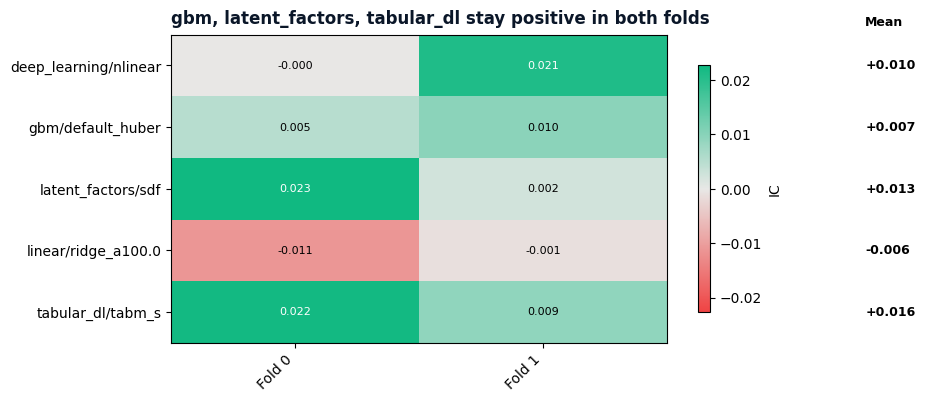

In [16]:
if fold_ic.height > 0:
    positive_all_folds = (
        fold_ic.group_by("model_label")
        .agg((pl.col("ic_mean") > 0).all().alias("positive_all"))
        .filter(pl.col("positive_all"))["model_label"]
        .sort()
        .to_list()
    )
    fold_title = (
        f"{', '.join(label.split('/')[0] for label in positive_all_folds)} "
        "stay positive in both folds"
        if positive_all_folds
        else "No family leader stays positive in both validation folds"
    )
    model_labels, fold_cols, matrix = plot_fold_heatmap(
        fold_ic,
        title=fold_title,
    )
else:
    model_labels, fold_cols, matrix = [], [], np.array([])

In [17]:
# Summary statistics per family
if fold_ic.height > 0:
    family_stats = (
        fold_ic.group_by("model_label")
        .agg(
            pl.col("ic_mean").mean().alias("mean_ic"),
            pl.col("ic_mean").median().alias("median_ic"),
            pl.col("ic_mean").std().alias("std_ic"),
            pl.col("ic_mean").min().alias("worst_fold"),
            pl.col("ic_mean").max().alias("best_fold"),
            (pl.col("ic_mean") > 0).mean().alias("pct_positive"),
            pl.col("ic_mean").count().alias("n_folds"),
        )
        .sort("mean_ic", descending=True)
    )
    print("Family performance summary:")
    print(family_stats)

Family performance summary:
shape: (5, 8)
┌──────────────┬───────────┬───────────┬──────────┬────────────┬───────────┬─────────────┬─────────┐
│ model_label  ┆ mean_ic   ┆ median_ic ┆ std_ic   ┆ worst_fold ┆ best_fold ┆ pct_positiv ┆ n_folds │
│ ---          ┆ ---       ┆ ---       ┆ ---      ┆ ---        ┆ ---       ┆ e           ┆ ---     │
│ str          ┆ f64       ┆ f64       ┆ f64      ┆ f64        ┆ f64       ┆ ---         ┆ u32     │
│              ┆           ┆           ┆          ┆            ┆           ┆ f64         ┆         │
╞══════════════╪═══════════╪═══════════╪══════════╪════════════╪═══════════╪═════════════╪═════════╡
│ tabular_dl/t ┆ 0.015656  ┆ 0.015656  ┆ 0.009367 ┆ 0.009032   ┆ 0.022279  ┆ 1.0         ┆ 2       │
│ abm_s        ┆           ┆           ┆          ┆            ┆           ┆             ┆         │
│ latent_facto ┆ 0.012547  ┆ 0.012547  ┆ 0.014274 ┆ 0.002454   ┆ 0.022641  ┆ 1.0         ┆ 2       │
│ rs/sdf       ┆           ┆           ┆         

The heatmap reads alongside Section 3's CI tiers. All five family
leaders now appear, including the null-checkpoint GBM and linear rows.
Their fold-level scatter reflects the compression around zero. The
broad cross-section improves precision *within* each fold; what
the two-fold setup cannot do is establish stability across time. The
combined picture is consistent with the Section 3 reading: none of the
highest-IC configurations clears credibility on `fwd_ret_5d` after
HAC inference, and the heatmap should not be read as evidence of
stable family superiority.

## 4. Stability Over Time

With only 2 folds, traditional stability analysis (IQR widths,
bimodal detection) is not meaningful. Box plots with 2 data points
are degenerate. Instead, we focus on two questions: (1) is each
family positive in both folds? and (2) does the fold ranking of
families change between folds?

### Two Folds Leave Family Rankings Fragile

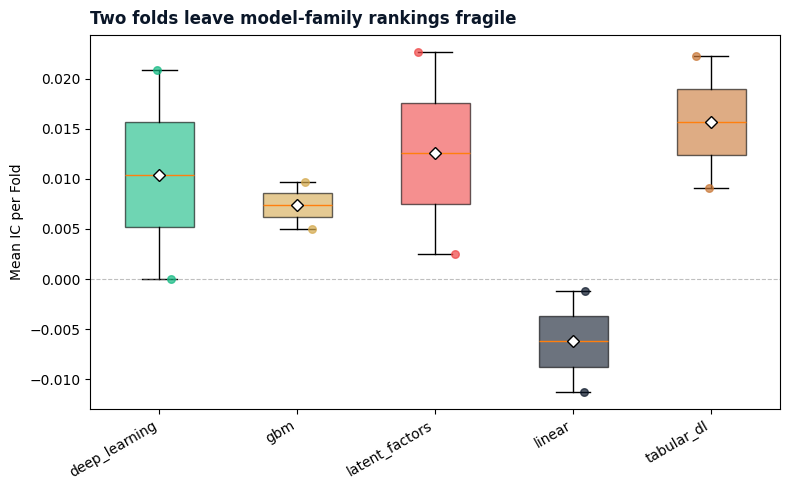

In [18]:
if fold_ic.height > 0:
    plot_fold_boxplot(
        fold_ic,
        title="Two folds leave model-family rankings fragile",
    )

With 2 folds and highest-IC point estimates compressed within
±0.020 of zero (§3), the box plots are minimally informative -
each "distribution" is two dots, and the inter-family overlap is
almost complete. The four positive highest-IC configurations
(`tabm_s`, SDF, NLinear, and `default_huber`) cluster together; the
ridge_a100.0 baseline sits below them. None of the families has
established time-series robustness in the formal sense on this
label, and the daily-pooled HAC CIs (§3) - which use the full
panel rather than the 2 fold-aggregates - are the binding
inference, not the per-fold IC dispersion.

## 5. What Are the Models Learning?

This section consolidates signal structure, model complexity, and feature
importance into a single diagnostic view. Three questions matter:

1. **Monotonicity**: do higher predicted scores correspond to higher
   realized returns? A monotonic relationship confirms ranking ability.
2. **Diversity**: do different model families produce similar or
   different rankings? Low correlation between families means ensemble
   value; high correlation means diminishing returns from complexity.
3. **Features**: which inputs drive the forecasts, and do option-derived
   features justify their data cost?

In [19]:
# Compute prediction bucket monotonicity for best model per family
bucket_results = {}
for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    mask = pl.col("prediction_hash") == row["prediction_hash"]

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    buckets = prediction_bucket_monotonicity(model_preds, N_BUCKETS, DATE_COL)
    if buckets.height > 0:
        bucket_results[family] = buckets

### TabM Has the Largest Positive Bucket Spread


Top-bottom bucket spread vs trading costs (3–10 bps per leg):
  tabular_dl            spread=+44 bps  edge/cost=7.3–2.2x
  latent_factors        spread=-3 bps  edge/cost=-0.5–-0.1x
  deep_learning         spread=+11 bps  edge/cost=1.8–0.5x
  gbm                   spread=-1 bps  edge/cost=-0.1–-0.0x
  linear                spread=+8 bps  edge/cost=1.3–0.4x


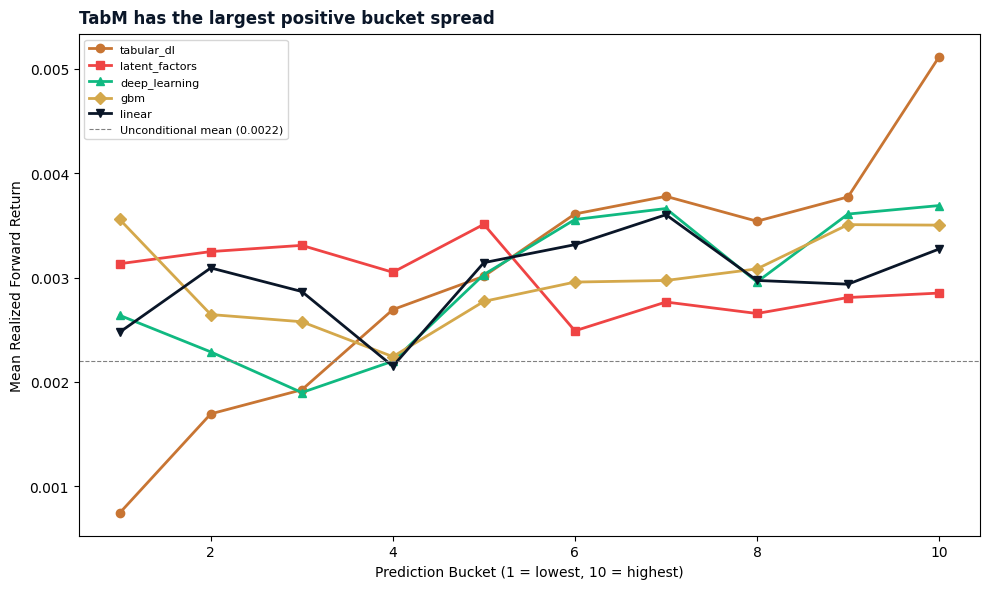

In [20]:
if bucket_results:
    unconditional_mean = best_preds["y_true"].mean() if best_preds.height > 0 else None
    plot_bucket_monotonicity(
        bucket_results,
        N_BUCKETS,
        unconditional_mean=unconditional_mean,
        cost_range=cost_range,
        title="TabM has the largest positive bucket spread",
    )

The decile plot is read alongside the 6-20 bps round-trip cost range.
TabM produces a 44 bps top-minus-bottom spread. NLinear and linear reach
11 and 8 bps, while SDF and GBM are approximately flat at -3 and -1 bps
despite positive mean IC. With only two validation
folds, these gross spreads are diagnostics rather than trading claims.
They reinforce the Section 3 result that the primary-label evidence is
weak and sensitive to the representation used.

In [21]:
# Pairwise prediction correlations
corr_matrix, corr_labels = (
    prediction_correlation_matrix(best_preds, date_col=DATE_COL, entity_col=ENTITY_COL)
    if best_preds.height > 0
    else (np.array([]), [])
)
if corr_matrix.size > 0 and len(corr_labels) >= 2:
    off_diagonal = corr_matrix[np.triu_indices(len(corr_labels), k=1)]
    print(
        f"Daily cross-sectional pairwise rank correlation: mean={off_diagonal.mean():.2f}, "
        f"range=[{off_diagonal.min():.2f}, {off_diagonal.max():.2f}]"
    )

Daily cross-sectional pairwise rank correlation: mean=0.05, range=[-0.13, 0.25]


### Model Rankings Share Limited Common Signal


Average pairwise correlation: 0.05
Range: -0.13 to 0.25


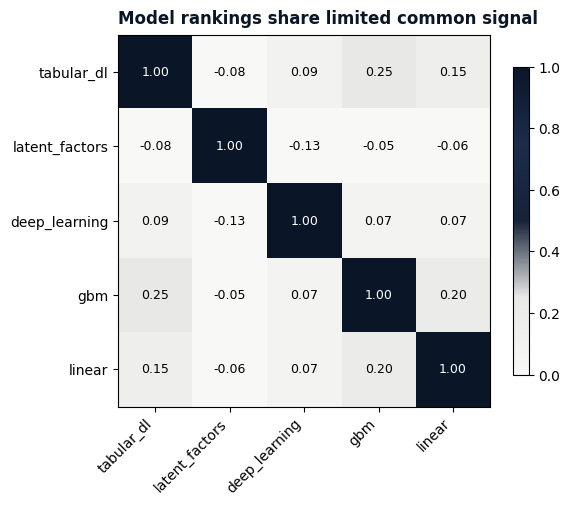

In [22]:
if corr_matrix.size > 0 and len(corr_labels) >= 2:
    plot_correlation_matrix(
        corr_matrix,
        corr_labels,
        title="Model rankings share limited common signal",
    )

Pairwise rank correlations are computed within each decision time and then
averaged over time, matching the cross-sectional ranking task.
The families are not redundant, but GBM and linear share a moderately
similar ranking. Because no family clears credibility
on `fwd_ret_5d`, the practical reading is not "ensemble of strong
diverse signals" but "ensemble of orthogonal weak signals" - useful
for label-routed allocation in §6 (different families have CI-
credible point estimates on different labels) more than for a
uniform §3 average. The structural-vs-supervised split in this
feature set - equity volatility, option implied surfaces,
momentum, and term-structure inputs - is consistent with different
extraction mechanisms (autoencoder factor rotation vs direct
feature-to-return mapping) producing genuinely different rankings.

### How Much Does Additional Model Complexity Help?

For models with checkpoint data, we observe how validation IC evolves
with training. This reveals where diminishing returns begin and
whether models overfit with additional epochs.

In [23]:
# Learning curves from pre-computed metrics (fast path)
cp_data = all_metrics.filter(pl.col("checkpoint_value").is_not_null())
if cp_data.height > 0:
    _curve_configs = (
        cp_data.group_by(["family", "config_name"])
        .agg(pl.col("checkpoint_value").n_unique().alias("n_cp"))
        .filter(pl.col("n_cp") > 1)
        .select("family", "config_name")
    )
    cp_data = cp_data.join(_curve_configs, on=["family", "config_name"], how="semi")
    cp_families = sorted(cp_data["family"].unique().to_list())
else:
    cp_families = []

print(f"Families with checkpoint data: {cp_families}")

Families with checkpoint data: ['latent_factors', 'tabular_dl']


### Checkpoint Sensitivity Differs Across Families

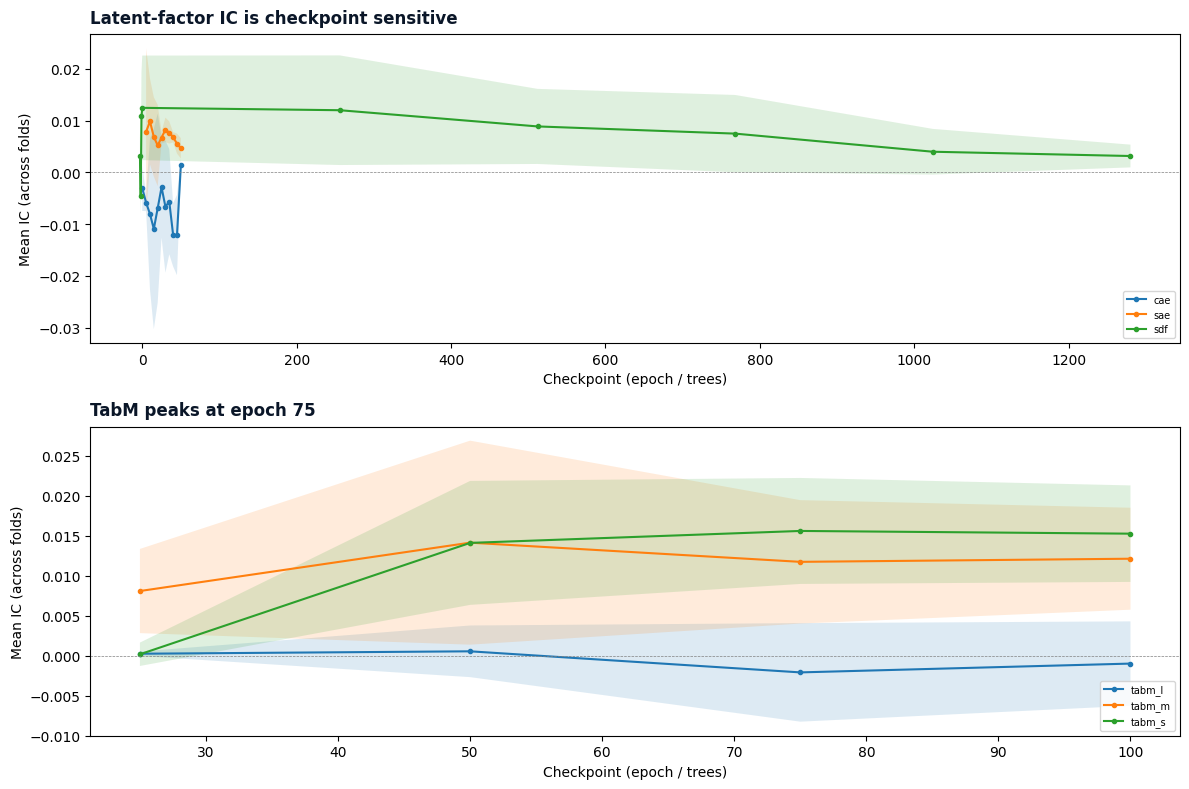

In [24]:
if cp_families:
    plot_learning_curves(
        cp_data,
        cp_families,
        titles={
            "latent_factors": "Latent-factor IC is checkpoint sensitive",
            "tabular_dl": "TabM peaks at epoch 75",
        },
    )

The learning curves show optimization dynamics for the families that
emit per-checkpoint metrics. With highest daily-pooled IC compressed
in a tight band (§3), the curve heights are small in absolute
terms; the informative patterns are about *shape* rather than
magnitude:

- **Latent factors**: oscillatory IC across checkpoints
  on this broad panel; checkpoint selection is fragile and
  the late-epoch ceiling is close to the early-epoch best.
- **Tabular DL (TabM)**: improves through the registered checkpoints and
  reaches the family's highest IC with `tabm_s` at epoch 75 (+0.0156),
  followed closely by epoch 100 (+0.0152).

The current GBM and Ch13 rows retain only one selected checkpoint per
configuration, so this notebook does not manufacture learning curves by
joining checkpoints from separate configs or executions. Their training
notebooks carry the exact-run checkpoint evidence.

The takeaway is that none of the families converts late-checkpoint
capacity into a CI-credible point estimate on `fwd_ret_5d`; early
stopping is appropriate for the deep families on this case study.

### Which Features Drive the Forecasts?

Feature importance is the most important subsection for this case study.
The central question is whether option-derived features - implied
volatility, skew, term structure, put-call ratios - appear among
the top predictors, or whether traditional equity momentum and
volatility features dominate. If option features do not rank highly,
the expensive option data adds no incremental value.

In [25]:
gbm_importance = load_gbm_feature_importance(CASE_STUDY, label=PRIMARY_LABEL, top_n=TOP_N_FEATURES)
importance_rows = []
merged = pl.DataFrame()

if gbm_importance is None:
    print("No GBM booster files available. Computing feature-prediction correlation as fallback...")
    features_path = CASE_DIR / "features" / "financial.parquet"
    if features_path.exists() and best_preds.height > 0:
        features_df = pl.read_parquet(features_path)
        feat_cols = [c for c in features_df.columns if c not in [DATE_COL, ENTITY_COL]]
        linear_preds = best_preds.filter(pl.col("family") == "linear")
        if linear_preds.height > 0:
            left_dtype = linear_preds[DATE_COL].dtype
            right_dtype = features_df[DATE_COL].dtype
            if left_dtype != right_dtype:
                target = pl.Datetime("ms")
                linear_preds = linear_preds.with_columns(pl.col(DATE_COL).cast(target))
                features_df = features_df.with_columns(pl.col(DATE_COL).cast(target))
            merged = linear_preds.join(features_df, on=[DATE_COL, ENTITY_COL], how="inner")

If booster gain data is unavailable, rank features by their within-fold
Spearman association with the selected linear model's score.

In [26]:
if gbm_importance is None and merged.height > 0:
    from scipy.stats import spearmanr

    for fold in sorted(merged["fold_id"].unique().drop_nulls().to_list()):
        fold_data = merged.filter(pl.col("fold_id") == fold)
        for feature in feat_cols:
            values = fold_data[[feature, "y_score"]].drop_nulls()
            if values.height <= 50:
                continue
            correlation, _ = spearmanr(values[feature].to_numpy(), values["y_score"].to_numpy())
            importance_rows.append(
                {
                    "config_name": "linear",
                    "fold_id": int(fold),
                    "feature": feature,
                    "importance": abs(float(correlation)),
                }
            )

Normalize the fallback inside each fold before retaining the most recurrent
features, so folds with different raw scales remain comparable.

In [27]:
if importance_rows:
    gbm_importance = pl.DataFrame(importance_rows).with_columns(
        (pl.col("importance") / pl.col("importance").max().over(["config_name", "fold_id"])).alias(
            "importance_norm"
        )
    )
    top_features = (
        gbm_importance.group_by("feature")
        .agg(pl.col("importance_norm").mean().alias("mean_imp"))
        .sort("mean_imp", descending=True)
        .head(TOP_N_FEATURES)["feature"]
        .to_list()
    )
    gbm_importance = gbm_importance.filter(pl.col("feature").is_in(top_features))
    print(
        f"Computed feature-score correlation for {len(top_features)} features "
        f"across {merged['fold_id'].n_unique()} folds"
    )

if gbm_importance is not None and gbm_importance.height > 0:
    _n_importance_features = gbm_importance["feature"].n_unique()
    _n_importance_folds = gbm_importance["fold_id"].n_unique()
    print(f"Feature importance: {_n_importance_features} features × {_n_importance_folds} folds")
else:
    print("Feature importance data not available.")

Feature importance: 15 features × 2 folds


### Term-Structure Slope Is the Most Stable Feature


Persistent features (top-5 in ≥75% of folds): ['term_slope_near_atm']

Option-derived features in top 15: 5 - ['term_slope_near_atm', 'iv_mom_5d', 'iv_7_atm', 'iv_mom_21d', 'iv_30_atm_z_63']
Equity features in top 15: 10 - ['mom_126d', 'rv_63', 'gk_vol_21', 'realized_skew_21', 'mom_skip_recent', 'garch_cond_vol', 'mom_21d', 'mom_252d', 'mom_63d', 'mom_63d_rank']


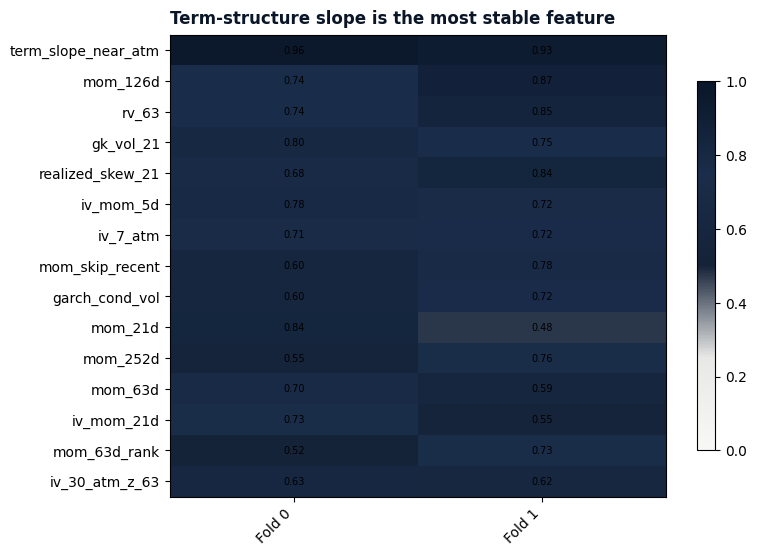

In [28]:
if gbm_importance is not None and gbm_importance.height > 0:
    plot_feature_importance_heatmap(
        gbm_importance,
        TOP_N_FEATURES,
        title="Term-structure slope is the most stable feature",
    )

    # Option vs equity feature breakdown
    option_keywords = [
        "put_call",
        "skew_rr",
        "vega",
        "theta",
        "delta",
        "gamma",
        "term_struct",
        "term_slope",
        "term_ratio",
        "ivrv",
        "implied",
        "oi_",
        "open_interest",
        "option",
    ]
    all_top_features = (
        gbm_importance.group_by("feature")
        .agg(pl.col("importance_norm").mean().alias("mean_imp"))
        .sort("mean_imp", descending=True)
        .head(TOP_N_FEATURES)["feature"]
        .to_list()
    )
    opt_in_top = [
        f
        for f in all_top_features
        if f.lower().startswith(("iv_", "ivrv_")) or any(kw in f.lower() for kw in option_keywords)
    ]
    eq_in_top = [f for f in all_top_features if f not in opt_in_top]
    print(f"\nOption-derived features in top {TOP_N_FEATURES}: {len(opt_in_top)} - {opt_in_top}")
    print(f"Equity features in top {TOP_N_FEATURES}: {len(eq_in_top)} - {eq_in_top}")

**Equity features outnumber option-derived features.** Five of the top
15 are option-derived: the near-ATM term slope plus four IV
level or momentum features. The remaining ten include price momentum,
realized volatility, Garman-Klass volatility, and realized skew.

The dominant equity-side features include **rv_63** (63-day realized
volatility), `gk_vol_21` (Garman-Klass volatility), and realized skew.
The near- and far-ATM term slopes and momentum at 21, 63, and 126 days
also appear.

The feature importance pattern tells a nuanced story:

1. **Volatility features dominate both sides**: both realized
   volatility (equity) and implied volatility (option) are the
   strongest individual predictors. The signal is fundamentally
   about volatility regime positioning.
2. **Option features add breadth**: five of 15 slots show that the
   option surface participates in the forecast, but this importance
   ranking is not an ablation and does not isolate incremental value.
3. **The IV-RV spread is absent**: ivrv_spread does not rank in the
   top 15, despite being the theoretically most interesting option
   feature. This may reflect high noise at the individual stock level.
4. **Momentum features are secondary**: mom_21d and mom_skip_recent
   appear but do not dominate, suggesting that pure price momentum
   is less important than volatility regime for weekly stock selection
   in S&P 500.

The feature-level view shows why joint equity-option structure remains
worth testing. It does not explain family superiority on the primary
label: SDF is the latent-factor leader there, and all family-leader CIs
still include zero.

## 6. Heterogeneity: Labels, Horizons, and Regimes

Signal strength may vary across prediction targets, forecast horizons,
and market regimes. This section examines all three dimensions.

### Multi-Label Comparison

Five labels were trained on this case study: the primary `fwd_ret_5d`
(weekly regression), a longer-horizon regression (`fwd_ret_10d`),
a risk-adjusted variant (`fwd_ret_risk_adj_5d`), and two directional
reframings (`fwd_dir_5d`, `fwd_dir_10d`). The forest below renders
the highest-IC config per family for each label as a point estimate
with its HAC 95% CI; tiles labeled "no run" mean a family was not
trained on that label, which is itself part of the diagnosis.

In [29]:
multi_rows = []
for lbl in [PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL]:
    lbl_metrics = all_labels_metrics.filter(pl.col("label") == lbl)
    for fam in lbl_metrics["family"].unique().to_list():
        fam_data = lbl_metrics.filter(pl.col("family") == fam)
        rank1 = fam_data.sort("ic_mean_daily", descending=True, nulls_last=True).head(1)
        if rank1.height == 0:
            continue
        r = rank1.row(0, named=True)
        if r.get("ic_mean_daily") is None:
            continue
        multi_rows.append(
            {
                "label": lbl,
                "family": fam,
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r.get("ic_ci_lo"),
                "ic_ci_hi": r.get("ic_ci_hi"),
                "ic_t_hac": r.get("ic_t_hac"),
            }
        )

multi_label_df = pl.DataFrame(multi_rows)
multi_label_df

label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_t_hac
str,str,str,f64,f64,f64,f64
"""fwd_ret_5d""","""linear""","""ridge_a100.0""",-0.006173,-0.034296,0.02195,-0.431252
"""fwd_ret_5d""","""latent_factors""","""sdf""",0.012446,-0.018881,0.043773,0.78056
"""fwd_ret_5d""","""tabular_dl""","""tabm_s""",0.015589,-0.002839,0.034016,1.662112
"""fwd_ret_5d""","""deep_learning""","""nlinear""",0.010526,-0.01024,0.031293,0.995909
"""fwd_ret_5d""","""gbm""","""default_huber""",0.007394,-0.009019,0.023806,0.885135
…,…,…,…,…,…,…
"""fwd_ret_10d""","""linear""","""ridge_a10.0""",0.009624,-0.02482,0.044068,0.548969
"""fwd_ret_10d""","""gbm""","""default_huber""",0.007082,-0.013815,0.027979,0.665863
"""fwd_ret_risk_adj_5d""","""latent_factors""","""pca""",0.044393,0.022218,0.066568,3.933276


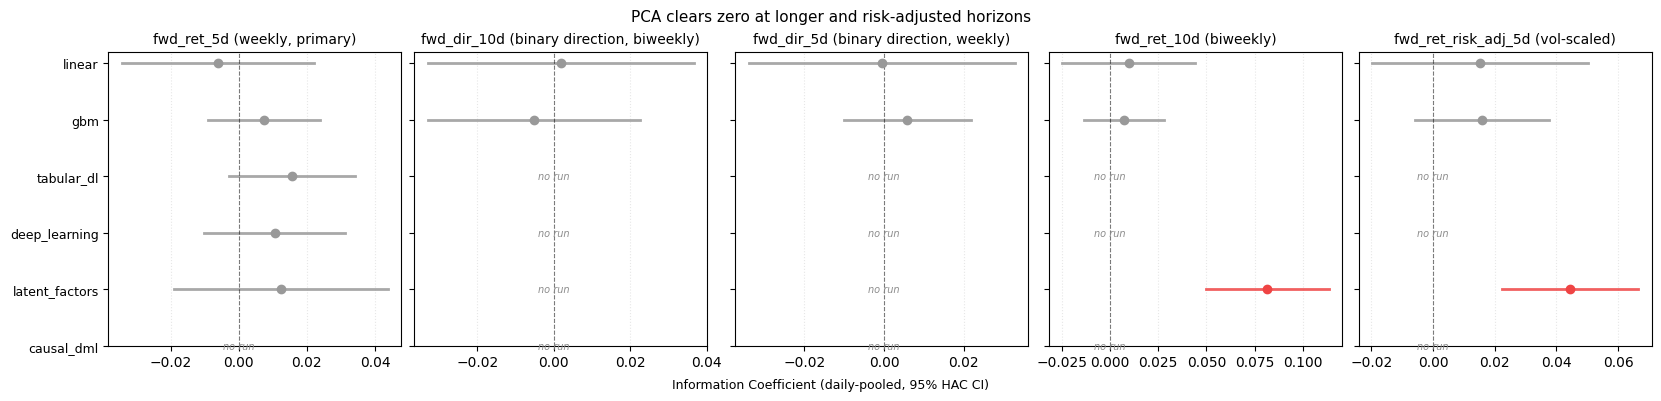

In [30]:
plot_label_horizon_forest(
    multi_label_df,
    families=["linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"],
    labels=[PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL],
    label_display={
        "fwd_ret_5d": "fwd_ret_5d (weekly, primary)",
        "fwd_ret_10d": "fwd_ret_10d (biweekly)",
        "fwd_ret_risk_adj_5d": "fwd_ret_risk_adj_5d (vol-scaled)",
        "fwd_dir_5d": "fwd_dir_5d (binary direction, weekly)",
        "fwd_dir_10d": "fwd_dir_10d (binary direction, biweekly)",
    },
    title="PCA clears zero at longer and risk-adjusted horizons",
)

Coverage is uneven across the panel. On the primary `fwd_ret_5d`
all five predictive and structural families have a registry entry, plus
causal DML has a primary-label estimate rendered separately in Section 7.
On `fwd_ret_10d` and `fwd_ret_risk_adj_5d` only linear, GBM, and
latent factors have runs; TabM and the Ch13 deep models
causal_dml are absent. On the two directional labels only linear
and GBM have runs - neither the deep families nor latent factors
were retrained on the binary targets. Causal_dml's missing tiles
are the same: the family ran a single ATE on the primary label.

The horizon picture is materially different from the §3 reading on
the primary label:

- **PCA clears the interval gate on two alternate labels.** On
  `fwd_ret_10d`, PCA reaches +0.0815 with HAC 95% CI
  [+0.0497, +0.1134] and $t = 5.02$. On `fwd_ret_risk_adj_5d`,
  PCA reaches +0.0444 with CI [+0.0222, +0.0666] and $t = 3.93$.
- **Directional reframings are weak on this case study**: linear
  `logistic_l1_C0.001` leads its family on `fwd_dir_5d` (-0.0006),
  while `logistic_l2_C100.0` leads on `fwd_dir_10d` (+0.0019). Both
  CIs straddle zero, and GBM's `default_binary` is essentially
  noise on `fwd_dir_5d` (+0.0058) and slightly negative on
  `fwd_dir_10d` (-0.0053). Unlike crypto perps or fx, where
  directional reframing rescued GBM/linear credibility, here the
  binary recasting does not gain CI separation.

The latent ranking changes with the target. SDF leads the latent family
on `fwd_ret_5d`, while PCA leads at both alternate regression labels.
The supervised families do not displace those alternate-label PCA
estimates. This is label-routing evidence, not evidence that one family
dominates across horizons.

### Regime Sensitivity

The S&P 500 equity+option universe has a natural regime variable:
the VIX (or its proxy, cross-sectional return dispersion). Option
features should be more informative in high-volatility periods,
when implied volatility surfaces contain more information about
future returns. In low-volatility environments, options are cheap,
IV surfaces are flat, and the incremental signal from option data
diminishes.

In [31]:
# Compute regime-conditional IC
regime_results = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    mask = pl.col("prediction_hash") == row["prediction_hash"]

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    regime_ic = regime_conditional_ic(model_preds, date_col=DATE_COL)
    if regime_ic.height > 0:
        regime_ic = regime_ic.with_columns(pl.lit(family).alias("family"))
        regime_results.append(regime_ic)

regime_df = pl.concat(regime_results) if regime_results else pl.DataFrame()

### Model Performance Changes Sign Across Volatility Regimes

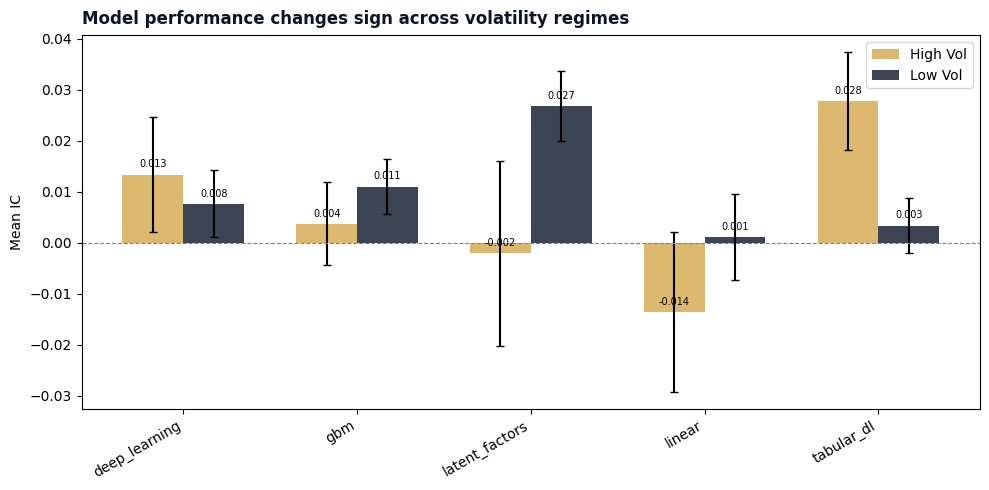

In [32]:
if regime_df.height > 0:
    plot_regime_bars(
        regime_df,
        title="Model performance changes sign across volatility regimes",
    )

The regime results do not support a single high-volatility advantage.
SDF changes from +0.0269 in low volatility to -0.0020 in high volatility,
while GBM remains positive but weakens from +0.0110 to +0.0037. TabM rises
from +0.0034 to +0.0278, and NLinear rises from +0.0077 to +0.0134. Linear
is weak in low volatility and turns negative at -0.0135 in high volatility.
These shifts argue against a static family ranking,
but two validation folds are too little evidence for regime-timed weights.

## 7. Structural and Causal Evidence

Not all model chapters produce comparable predictive scores. Ch14
(latent factors) extracts structure; Ch15 (causal DML) estimates
treatment effects. These require separate evidence blocks.

### Latent Factors (Ch14)

All five latent factor models were trained on the configured S&P 500
Equity+Options roster. The broad validation cross-section
and rich option-implied features makes this the most informative
latent-factor case study in the book - even where supervised IC
straddles zero on the primary label, the structural variants extract
stable factor structure and reach CI credibility on the 10-day and
vol-normalized horizons (Section 6: PCA on both labels).

In [33]:
# Load latent factor diagnostics
lf_models = ["pca", "ipca", "cae", "sdf", "sae"]
lf_extras = {m: load_fold_extras(CASE_STUDY, m) for m in lf_models}
lf_extras = {m: e for m, e in lf_extras.items() if e is not None}

# Print IC summary from registry
lf_metrics = all_labels_metrics.filter(
    pl.col("family") == "latent_factors", pl.col("label") == PRIMARY_LABEL
)
if lf_metrics.height > 0:
    lf_best = (
        lf_metrics.group_by("config_name")
        .agg(ic=pl.col("ic_mean_daily").max())
        .sort("ic", descending=True)
    )
    print(f"Latent factor IC on {PRIMARY_LABEL}:")
    for row in lf_best.iter_rows(named=True):
        print(f"  {row['config_name']:6s}: {row['ic']:+.4f}")

    # Show best supervised for comparison
    sup_metrics = all_labels_metrics.filter(
        pl.col("family").is_in(["linear", "gbm", "tabular_dl", "deep_learning"]),
        pl.col("label") == PRIMARY_LABEL,
    )
    if sup_metrics.height > 0:
        sup_best = sup_metrics.sort("ic_mean_daily", descending=True).head(1)
        print(f"\nBest supervised: {sup_best['family'][0]} IC={sup_best['ic_mean_daily'][0]:+.4f}")

print(f"\nFold extras available: {list(lf_extras.keys())}")

Latent factor IC on fwd_ret_5d:
  sdf   : +0.0124
  sae   : +0.0098
  cae   : +0.0014
  ipca  : -0.0018
  pca   : -0.0126

Best supervised: tabular_dl IC=+0.0156

Fold extras available: ['pca', 'ipca', 'cae', 'sdf', 'sae']


#### PCA Variance Decomposition

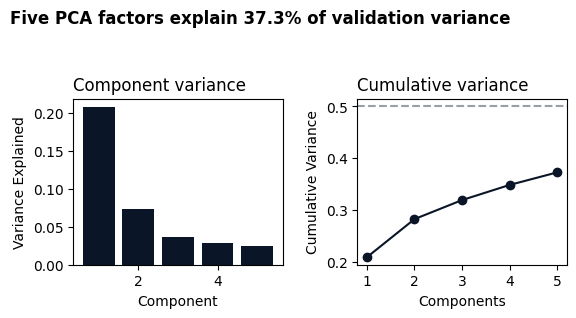

In [34]:
if "pca" in lf_extras:
    var_ratios = [e["explained_variance_ratio"] for e in lf_extras["pca"]]
    mean_var = np.mean(var_ratios, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE["dual_h_tall"])
    axes[0].bar(range(1, len(mean_var) + 1), mean_var, color=COLORS["blue"])
    axes[0].set_xlabel("Component")
    axes[0].set_ylabel("Variance Explained")
    axes[0].set_title("Component variance", loc="left")

    axes[1].plot(range(1, len(mean_var) + 1), np.cumsum(mean_var), marker="o", color=COLORS["blue"])
    axes[1].set_xlabel("Components")
    axes[1].set_ylabel("Cumulative Variance")
    axes[1].set_title("Cumulative variance", loc="left")
    axes[1].axhline(0.5, ls="--", color=COLORS["neutral"], alpha=0.5)
    fig.suptitle(
        f"Five PCA factors explain {sum(mean_var):.1%} of validation variance",
        x=0.02,
        ha="left",
        fontweight="semibold",
    )
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    fig.show()

**Interpretation**: The scree plot shows how variance concentrates
across the broad equity+option validation cross-section. The steep initial
drop indicates a small number of dominant factors - consistent with
the well-documented factor structure of S&P 500 returns. The
cumulative curve reveals how many components are needed to capture
the majority of cross-sectional variation in this joint
equity+option feature space.

#### IPCA Characteristic Loadings ($\Gamma$ Matrix)

The $\Gamma$ matrix maps the 48 equity+option characteristics to
latent factor loadings. Option-implied features (IV, skew, term
structure) that load heavily suggest the model captures
volatility-regime-based factor structure.

In [35]:
if "ipca" in lf_extras:
    last_fold = lf_extras["ipca"][-1]
    if "Gamma" in last_fold:
        Gamma = np.array(last_fold["Gamma"])
        n_chars, n_factors = Gamma.shape

        # Load feature names
        feat_names = []
        for fname in ["financial.parquet", "model_based.parquet"]:
            fpath = CASE_DIR / "features" / fname
            if fpath.exists():
                cols = pl.scan_parquet(fpath).collect_schema().names()
                feat_names.extend(
                    c
                    for c in cols
                    if c not in {"symbol", "timestamp", "date", "asset"}
                    and not c.startswith("fwd_")
                )

        # Top 10 characteristics per factor
        n_top = min(10, n_chars)
        panel_count = min(3, n_factors)
        size_key = {1: "single_tall", 2: "dual_h_tall", 3: "triple_h_tall"}[panel_count]
        fig, axes = plt.subplots(1, panel_count, figsize=FIGSIZE[size_key])
        if panel_count == 1:
            axes = [axes]
        for k, ax in enumerate(axes):
            col = Gamma[:, k]
            top_idx = np.argsort(np.abs(col))[-n_top:][::-1]
            labels = [feat_names[i][:25] if i < len(feat_names) else f"feat_{i}" for i in top_idx]
            vals = col[top_idx]
            colors = [COLORS["blue"] if v > 0 else COLORS["negative"] for v in vals]
            ax.barh(range(n_top), vals, color=colors)
            ax.set_yticks(range(n_top))
            ax.set_yticklabels(labels, fontsize=8)
            ax.set_title(f"Factor {k + 1}")
            ax.invert_yaxis()
        fig.suptitle("IPCA: Top Characteristics per Factor")
        fig.tight_layout()
        fig.show()

**Interpretation**: The $\Gamma$ matrix reveals which of the 48
characteristics drive time-varying factor loadings. Option-implied
features (IV levels, skew, term structure) that appear prominently
confirm that IPCA captures volatility-regime-driven factor rotation
- loadings shift as the IV surface changes, creating factors that
are distinct from static PCA components.

#### CAE / SAE Training Convergence

CAE and SAE training on the SP500 Eq+Opt panel converges through
the configured epoch budget, but the per-fold IC trajectory
(§5 learning curves) is non-monotonic on this case study. The loss
curves below show whether the optimization itself is stable across
folds - separating "the optimizer didn't converge" from
"the optimizer converged but the fold-to-fold IC is volatile".

In [36]:
for model_name in ["cae", "sae"]:
    if model_name not in lf_extras:
        continue
    loss_curves = []
    for fold in lf_extras[model_name]:
        losses = fold.get("epoch_losses", {})
        if losses:
            epochs = sorted(int(k) for k in losses)
            loss_curves.append((fold["fold_id"], epochs, [losses[str(e)] for e in epochs]))
    if not loss_curves:
        continue
    fig, ax = plt.subplots(figsize=FIGSIZE["single"])
    for fold_id, epochs, values in loss_curves:
        ax.plot(epochs, values, alpha=0.6, label=f"Fold {fold_id}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{model_name.upper()} loss converges across available folds", loc="left")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.show()

**Interpretation**: The loss curves show convergence behavior for the
autoencoder architectures when loss histories are available. Smooth,
monotonic decline indicates stable
learning of the cross-sectional factor structure. Erratic or
non-monotonic loss suggests sensitivity to mini-batch composition in
this broad universe, consistent with the checkpoint fragility
observed in the IC learning curves above.

#### SDF Sharpe Ratios

In [37]:
if "sdf" in lf_extras:
    sharpes = [e.get("sdf_sharpe", None) for e in lf_extras["sdf"]]
    sharpes = [s for s in sharpes if s is not None]
    if sharpes:
        print(f"SDF Sharpe across folds: mean={np.mean(sharpes):.3f}, std={np.std(sharpes):.3f}")
        print(f"  Range: [{min(sharpes):.3f}, {max(sharpes):.3f}]")

SDF Sharpe across folds: mean=0.717, std=0.032
  Range: [0.685, 0.750]


**Interpretation**: The SDF Sharpe ratio measures the pricing kernel's
ability to price the cross-section. The SDF's objective (minimizing
pricing errors) is not aligned with the cross-sectional ranking
objective IC measures, so the SDF's predictive IC on `fwd_ret_5d`
(read from the latent-factor IC summary above) being weaker than
its in-sample factor Sharpe is the expected pattern, not a defect.
The pricing-kernel framing remains useful for the no-arbitrage
decomposition exercise in Ch14 even when ranking IC is small.

### Causal DML (Ch15)

In [38]:
# Load primary-label causal DML evidence from the dedicated registry table.
import json as _json
import sqlite3

_db_path = CASE_DIR / "run_log" / "registry.db"
causal_rows = []
if _db_path.exists():
    with sqlite3.connect(_db_path) as _con:
        _cur = _con.execute(
            "SELECT label, treatment, dml_effect, dml_se_hac, p_value_hac, "
            "naive_effect, confounding_bias_pct, refutation_p, n_obs, embargo, "
            "confounders_json FROM causal_runs WHERE label = ? ORDER BY label",
            (PRIMARY_LABEL,),
        )
        for row in _cur.fetchall():
            d = dict(zip([c[0] for c in _cur.description], row))
            d["confounders"] = _json.loads(d.pop("confounders_json"))
            causal_rows.append(d)


def _fmt(val, spec):
    return format(val, spec) if val is not None else "n/a"


if causal_rows:
    print(f"Causal DML - {len(causal_rows)} run(s):")
    for r in causal_rows:
        ate = r["dml_effect"]
        se = r["dml_se_hac"]
        t = ate / se if (ate is not None and se) else None
        print(
            f"  {r['label']:14s} treatment={r['treatment']:24s} "
            f"ATE={_fmt(ate, '+.6f')}  SE_HAC={_fmt(se, '.6f')}  "
            f"t={_fmt(t, '+.2f')}  p={_fmt(r['p_value_hac'], '.3g')}  "
            f"bias%={_fmt(r['confounding_bias_pct'], '+.1f')}  "
            f"refutation_p={_fmt(r['refutation_p'], '.2f')}"
        )
else:
    print("No causal DML results available for this case study")

Causal DML - 1 run(s):
  fwd_ret_5d     treatment=ivrv_spread              ATE=-0.022823  SE_HAC=0.020006  t=-1.14  p=0.257  bias%=-0.5  refutation_p=0.01


Causal DML estimates the conditional effect of `ivrv_spread` on weekly
forward returns after adjustment for the declared confounders. The
corrected development-period run reports an effect of -0.022823 with
Driscoll-Kraay SE 0.020006 ($t = -1.14$, $p = 0.257$). The naive
same-sample naive coefficient is -0.022934, for a signed adjustment of
-0.49%. The within-entity block-permutation diagnostic passes at $p = 0.01$.

The diagnostics disagree: the coefficient is not distinguishable from
zero under panel-robust inference, while its magnitude is unusual in the
finite permutation distribution. This is not the same information the
supervised models use. The DML coefficient is a conditional treatment
estimate, not a cross-sectional IC, and its causal interpretation still
depends on conditional ignorability, overlap, and SUTVA.

For strategy design, `ivrv_spread` remains a plausible feature with a
negative adjusted coefficient. The evidence is not strong enough to use
that sign as a binding portfolio prior or to claim that the channel is
causally established.

### Calibration: Do Prediction Intervals Reach Their Nominal Coverage?

Point IC tells us whether the ranking is correct on average; it says
nothing about whether the model's *uncertainty* is well calibrated.
Inductive split-conformal prediction (Vovk et al., 2005; Lei et al.,
2018) gives a distribution-free check: using the earliest validation
fold's absolute residuals as a calibration set, the symmetric quantile
$\hat{q}_{1-\alpha}$ defines an interval
$[\hat{y} - \hat{q}, \hat{y} + \hat{q}]$ that should cover the true
label at rate $1-\alpha$ on later folds.
Empirical coverage materially below the nominal level signals
overconfident residual scaling: the model misses more often
than its training-time spread suggests. Width is reported as a
fraction of the actuals' standard deviation so families with different
return scales are comparable; smaller width at matched coverage means
tighter, more useful intervals. See Ch12 §12.6 / `11_conformal_gbm`
for the full conformal toolkit (CQR, ACI). What we report here is the
minimal residual-calibration diagnostic on the highest-IC config per
family for the primary label.

In [39]:
conformal_df = conformal_coverage_diagnostic(CASE_STUDY, label=PRIMARY_LABEL)
conformal_df

family,config_name,nominal_level,empirical_coverage,mean_interval_width_frac_std,n_test
str,str,f64,f64,f64,i64
"""deep_learning""","""nlinear""",0.8,0.398398,1.478255,102360
"""deep_learning""","""nlinear""",0.9,0.512759,2.01265,102360
"""deep_learning""","""nlinear""",0.95,0.618542,2.585319,102360
"""gbm""","""default_huber""",0.8,0.59702,1.493211,103973
"""gbm""","""default_huber""",0.9,0.713637,2.058385,103973
…,…,…,…,…,…
"""linear""","""ridge_a100.0""",0.9,0.716301,1.919327,103973
"""linear""","""ridge_a100.0""",0.95,0.803968,2.505962,103973
"""tabular_dl""","""tabm_s""",0.8,0.603176,1.462522,103973


In [40]:
if conformal_df.height > 0:
    pivot = conformal_df.pivot(
        on="nominal_level",
        index=["family", "config_name"],
        values=["empirical_coverage", "mean_interval_width_frac_std"],
    )
    print("Empirical coverage and width (× std of returns) at 80/90/95% nominal:")
    print(pivot)

Empirical coverage and width (× std of returns) at 80/90/95% nominal:
shape: (5, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config_nam ┆ empirical_ ┆ empirical ┆ empirical ┆ mean_inte ┆ mean_inte ┆ mean_inte │
│ ---        ┆ e          ┆ coverage_0 ┆ _coverage ┆ _coverage ┆ rval_widt ┆ rval_widt ┆ rval_widt │
│ str        ┆ ---        ┆ .8         ┆ _0.9      ┆ _0.95     ┆ h_frac_st ┆ h_frac_st ┆ h_frac_st │
│            ┆ str        ┆ ---        ┆ ---       ┆ ---       ┆ d_0…      ┆ d_0…      ┆ d_0…      │
│            ┆            ┆ f64        ┆ f64       ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ deep_learn ┆ nlinear    ┆ 0.398398   ┆ 0.512759  ┆ 0.618542  ┆ 1.478255  ┆ 2.01265   ┆ 2.585319  │
│ ing  

All five families materially **under-cover** at every level. Empirical
coverage is 18–40 pp below nominal at 80%, 17–39 pp below at 90%, and
13–33 pp below at 95%. Residuals in the later validation fold are much
wider than the earliest-fold calibration suggests:

- **Linear `ridge_a100.0`**: 0.597 / 0.716 / 0.804 (vs nominal
  0.80 / 0.90 / 0.95), widths 1.39 / 1.92 / 2.51σ - the tightest
  intervals, but still substantially below target coverage.
- **Latent factors `sdf`**: 0.615 / 0.734 / 0.815, widths
  1.47 / 2.03 / 2.62 standard deviations.
- **Tabular DL `tabm_s`**: 0.603 / 0.725 / 0.808, widths
  1.46 / 2.03 / 2.64 standard deviations.
- **GBM `default_huber`**: 0.597 / 0.714 / 0.797, widths
  1.49 / 2.06 / 2.65 standard deviations.
- **Deep learning `nlinear`**: 0.398 / 0.513 / 0.619, widths
  1.48 / 2.01 / 2.59σ. It has the largest coverage shortfall at
  every nominal level.

The calibration result is non-trivial for Ch19 risk management.
All five static intervals are too narrow out of time, so a deployed
sleeve that froze the earliest-fold quantile would understate residual
uncertainty and risk oversizing positions. NLinear shows the most severe
shift. ACI extensions (Ch12 §12.6) that update interval width online are
the right next step before using these intervals for sizing.

## 8. Pre-Backtest Judgment and Handoff

We synthesize the evidence into explicit recommendations. Not every
model that was trained deserves a backtest - advancing fragile models
wastes compute and risks false confidence from overfitting the
backtest configuration.

Fold summaries complement the daily-pooled selection statistic without
treating two folds as a precise sampling distribution.

In [41]:
def fold_stability(
    family: str, config: str, ic_mean: float, ic_std: float
) -> tuple[float, float, float, float]:
    label_key = f"{family}/{config}"
    fam_folds = (
        fold_ic.filter(pl.col("model_label") == label_key) if fold_ic.height > 0 else pl.DataFrame()
    )
    if fam_folds.height > 0:
        fold_ics = fam_folds["ic_mean"].to_numpy()
        return (
            float(np.median(fold_ics)),
            float(np.std(fold_ics)),
            float((fold_ics > 0).mean()),
            float(np.min(fold_ics)),
        )
    return ic_mean, ic_std, float(ic_mean > 0), ic_mean

Recommendations combine the daily IC sign, two-fold stability, and realized
bucket spread. They remain validation diagnostics rather than holdout claims.

In [42]:
synthesis_rows = []
for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    ic_mean = row["ic_mean_daily"]
    median_ic, std_ic, pct_pos, worst = fold_stability(
        family, config, ic_mean, row.get("ic_std") or 0
    )
    spread = 0.0
    if family in bucket_results:
        b = bucket_results[family]
        if b.height >= 2:
            spread = (
                b.filter(pl.col("bucket") == N_BUCKETS)["mean_return"][0]
                - b.filter(pl.col("bucket") == 1)["mean_return"][0]
            )
    if median_ic > 0 and pct_pos > 0.6 and spread > 0:
        recommendation = "Backtest"
    elif ic_mean > 0:
        recommendation = "Backtest (marginal)"
    else:
        recommendation = "Exclude"
    synthesis_rows.append(
        {
            "family": family,
            "config": config,
            "ic_mean": round(ic_mean, 4),
            "ic_median": round(median_ic, 4),
            "ic_std": round(std_ic, 4),
            "pct_positive": round(pct_pos, 2),
            "worst_fold": round(worst, 4),
            "spread_bps": round(spread * 10000, 0),
            "recommendation": recommendation,
        }
    )

synthesis = pl.DataFrame(synthesis_rows).sort("ic_mean", descending=True)
print("Synthesis Table:")
print(synthesis)

Synthesis Table:
shape: (5, 9)
┌────────────┬───────────┬─────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config    ┆ ic_mean ┆ ic_median ┆ … ┆ pct_posit ┆ worst_fol ┆ spread_bp ┆ recommend │
│ ---        ┆ ---       ┆ ---     ┆ ---       ┆   ┆ ive       ┆ d         ┆ s         ┆ ation     │
│ str        ┆ str       ┆ f64     ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│            ┆           ┆         ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ str       │
╞════════════╪═══════════╪═════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ tabular_dl ┆ tabm_s    ┆ 0.0156  ┆ 0.0157    ┆ … ┆ 1.0       ┆ 0.009     ┆ 44.0      ┆ Backtest  │
│ latent_fac ┆ sdf       ┆ 0.0124  ┆ 0.0125    ┆ … ┆ 1.0       ┆ 0.0025    ┆ -3.0      ┆ Backtest  │
│ tors       ┆           ┆         ┆           ┆   ┆           ┆           ┆           ┆ (marginal │
│            ┆           ┆         ┆           ┆   ┆        

### Recommendations

Reading is organized by CI tier on the primary label, then by which
alternate label rescues credibility. With every highest-IC family on
`fwd_ret_5d` straddling zero, no family advances "strong" on the
weekly regression target.

**CI-credible on `fwd_ret_5d` (primary):** none. All four families
with a daily-pooled IC point estimate above zero (`tabm_s` +0.0156,
SDF +0.0124, NLinear +0.0105, `default_huber` +0.0074) have
HAC 95% CIs that straddle zero; `ridge_a100.0` sits at -0.0062, also
straddles-zero.

**CI-credible on alternate labels:**
- **PCA on `fwd_ret_10d`**: daily-pooled IC +0.0815, HAC 95% CI
  [+0.0497, +0.1134], $t = 5.02$.
- **PCA on `fwd_ret_risk_adj_5d`**: daily-pooled IC +0.0444, HAC 95% CI
  [+0.0222, +0.0666], $t = 3.93$.

**Positive on the primary label, but its interval straddles zero:**
- **Latent factors (SDF)**: highest primary-label latent IC is +0.0124.
  Its interval includes zero, so the stronger structural evidence comes
  from the alternate-label PCA runs above.
- **Tabular DL (`tabm_s`)**: only trained on `fwd_ret_5d`; +0.0156
  point estimate and the largest HAC t-stat among the positive families
  ($t = 1.66$). It was not trained on the alternate labels and
  would be the natural next training target if a TabM sleeve is
  wanted.
- **Deep learning (NLinear)**: only trained on `fwd_ret_5d`;
  +0.0105 with CI straddling zero ($t = 1.00$). As with TabM,
  alternate-label runs would clarify whether the temporal
  architecture rescues credibility on `fwd_ret_10d`.
- **GBM (`default_huber`)**: the primary-label leader is +0.0074.
  GBM family leaders range from +0.0071 to +0.0158 across regression
  labels and fall below zero on `fwd_dir_10d`.

**Causal DML (separate framing):**
- **`ivrv_spread` on `fwd_ret_5d`**: adjusted coefficient -0.022823,
  Driscoll-Kraay $t = -1.14$, $p = 0.257$, signed bias -0.49%, and
  permutation $p = 0.01$. The sign is negative, but panel-robust
  inference does not separate it from zero.

**Conformal calibration caveats (§7):**
- All five family leaders **under-cover** at every nominal level when the
  earliest validation fold calibrates the later fold. Static intervals
  would understate uncertainty and risk oversizing; NLinear has the
  largest coverage shortfall.

### Forecast Representation

For backtesting, predictions should be used as:
- **Rank-based selection**: sort by `y_score`, select top-N stocks
  (top decile = about 55 stocks in the current validation panels)
- **Label routing**: latent-factor sleeve runs on
  the alternate-label PCA candidates, not the primary-label latent
  estimate. Supervised sleeves remain exploratory on `fwd_ret_5d`.
- **Ensemble**: low pairwise correlation across families means
  small averaging gains; weight by CI tightness, not by point
  estimate magnitude.

### The Option Feature Question

Do option-derived features justify their data cost? The evidence
is more nuanced than the original framing of this case study
suggested:

- Five of the top 15 features by importance are option-derived. The
  alternate-label panel shows that structural PCA is the family-label
  combination that reaches CI credibility at the 10-day and
  risk-adjusted horizons.
- The corrected causal DML estimate has a negative sign, but its
  Driscoll-Kraay p-value is 0.257. It does not establish that the
  volatility-risk-premium channel survives panel-robust inference.
- However, on the primary `fwd_ret_5d` regression, the
  equity+option feature set does not produce a CI-credible config
  in any family - including latent factors. Under HAC inference,
  all highest-IC estimates on `fwd_ret_5d` cluster within their
  joint CI overlap (point-estimate gaps between families are
  smaller than the HAC standard error).

Practical answer: option features participate in the strongest
alternate-label structural results, but this notebook does not run an
equity-only ablation. The data therefore remains justified for testing
the structural and risk-adjusted routes, while the claim of incremental
value remains open. It is not sufficient to make a supervised family
CI-credible on `fwd_ret_5d`.

### What This Analysis Does Not Tell Us

- **Conformal-corrected sizing**: the §7 under-coverage gaps across
  all five families mean that static interval widths understate later-fold
  uncertainty; ACI-based online updates (Ch12 §12.6) would replace
  the frozen calibration quantile before sizing.
- **Transaction costs under weekly rebalancing**: decile spreads
  are small in absolute terms and must survive round-trip costs of
  6–20 bps for liquid S&P 500 names; with weekly rebalancing,
  turnover compounds the cost drag.
- **Option data cost**: S&P 500 option data from vendors like
  OptionMetrics or CBOE costs \$5,000–\$50,000/year; the case
  for the option-derived features is anchored on PCA at the alternate
  regression labels and should be tested with an explicit ablation,
  not inferred from weekly supervised prediction.
- **Survivorship bias**: the configured 633-stock roster was selected
  from current S&P 500 constituents with listed options; a prospective
  universe would include stocks that were later removed.
- **Capacity**: S&P 500 stocks trade >\$100M daily; a top-decile
  (~55-stock in the current validation panel) portfolio faces no capacity constraints at the
  sizing implied by the small IC magnitudes in §3.

**Next**: [`14_backtest`](14_backtest.ipynb) for strategy simulation,
[`15_portfolio_management`](15_portfolio_management.ipynb) for position sizing, and
`18_strategy_analysis.py` for end-to-end results.

## Key Takeaways

1. **No family clears credibility on `fwd_ret_5d`**: highest-IC
   point estimates cluster within +/-0.020 of zero: `tabm_s` +0.0156,
   SDF +0.0124, NLinear +0.0105, `default_huber` +0.0074,
   and `ridge_a100.0` -0.0062 - and every HAC 95% CI straddles zero.
   Daily-pooled IC with the HAC adjustment is the controlling
   measure here; cross-family point-estimate gaps are smaller
   than the HAC standard error
2. **Two alternate labels clear the interval gate for PCA**:
   PCA reaches daily-pooled IC +0.0815 on `fwd_ret_10d` and +0.0444 on
   `fwd_ret_risk_adj_5d`; both HAC 95% CIs exclude zero. The
   latent-factor sleeve should be label-routed rather than inferred
   from the primary `fwd_ret_5d`
3. **Causal DML remains diagnostic, not confirmatory**: the corrected
   coefficient is -0.022823 with Driscoll-Kraay $t = -1.14$ and
   $p = 0.257$. The permutation diagnostic passes at 0.01, but the
   panel-robust interval includes zero and identification assumptions
   remain untested
4. **Prediction diversity is high but rests on weak signals**:
   pairwise rank correlations are low across the highest-IC
   configurations. Because no family clears credibility on the
   primary label, this is "diverse weak signals" not "diverse
   strong signals". Ensemble averaging gives small gains;
   label-routed allocation is the better Ch20 input
5. **Conformal intervals uniformly under-cover out of time**: all five
   family leaders miss nominal coverage by about 13-40 pp across the three
   levels. NLinear has the largest shortfall. None reaches nominal
   calibration on the later validation fold, so static interval sizing
   is not deployment-ready

**Next**: [`14_backtest`](14_backtest.ipynb) applies these predictions to simulated trading.